# Fused Softmax

在本教程中，您将编写一个融合的 softmax 操作，该操作在某些类别的矩阵上比 PyTorch 的原生操作快得多：即那些可以适应 GPU 静态随机存取存储器 (SRAM) 的行。

通过这个过程，您将了解以下内容：

+ 内核融合对于带宽受限操作的优势。
+ Triton 中的 Reduction operators。

## Motivation

让我们考虑一个传统意义上的 Softmax 操作：

In [1]:
import torch
import triton
import triton.language as tl

from triton.runtime import driver

DEVICE = triton.runtime.driver.active.get_active_torch_device()

def is_hip():
    return triton.runtime.driver.active.get_current_target().backend == "hip"

def is_cdna():
    return is_hip() and triton.runtime.driver.active.get_current_target().arch in ('gfx940', 'gfx941', 'gfx942',
                                                                                   'gfx90a', 'gfx908')

def naive_softmax(x):
    """
    使用原生 PyTorch 计算 X 的逐行 softmax
    """
    x_max = torch.max(x, dim=1)[0]
    x_new = x - x_max

    numerator  = torch.exp(x_new)
    denominator = torch.sum(numerator , dim=1)

    result = numerator/denominator # 用到了torch 中的广播机制
    # result = numerator / denominator[:, None]
    return result

直接在python中使用torch实现时，对于 $x \in \Bbb{R} ^ {M\times N}$，计算 $y=native\_softmax(x)$ 需要从DRAM中读取 $5MN+2M$ 个元素，写回 $3MN+2M$ 个元素。

这显然是浪费的；我们更希望有一个自定义的「融合」内核，它只需读取一次 X，并在芯片上进行所有必要的计算。

这样做只需要读写 $MN$ 字节，因此我们可以期望理论上的加速约为 4 倍（即 $\frac{8MN+4M}{2MN}$ ）。

torch.jit.script 标志旨在自动执行这种「内核融合」，但正如我们后面将看到的，它仍不够理想。

## Compute Kernel

softmax 内核工作原理如下：每个程序加载输入矩阵 X 的一组行，按程序数量跨步处理，对其进行归一化，并将结果写回输出 Y。

注意，Triton 的一个重要限制是每个块必须具有 2 的幂次数的元素，因此，如果我们要处理任意可能的输入形状，我们需要在内部「填充」每一行，并适当保护内存操作。

In [2]:
@triton.jit
def softmax_kernel(
    output_ptr, 
    input_ptr, 
    input_row_stride, 
    output_row_stride, 
    n_rows, 
    n_cols, 
    BLOCK_SIZE: tl.constexpr,
    num_stages: tl.constexpr):
    # starting row of the program
    # 程序起始行
    row_start = tl.program_id(0)
    row_step = tl.num_programs(0)
    for row_idx in tl.range(row_start, n_rows, row_step, num_stages=num_stages):
        # The stride represents how much we need to increase the pointer to advance 1 row
        # 步长表示我们需要对指针增加多少以推进 1 行
        row_start_ptr = input_ptr + row_idx * input_row_stride
        # The block size is the next power of two greater than n_cols, so we can fit each
        # 块大小是大于 n_cols 的下一个二的幂，因此我们可以适配
        # row in a single block
        # 单个块中的行
        col_offsets = tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets
        # Load the row into SRAM, using a mask since BLOCK_SIZE may be > than n_cols
        # 将行加载到 SRAM 中，使用掩码，因为 BLOCK_SIZE 可能大于 n_cols
        mask = col_offsets < n_cols
        row = tl.load(input_ptrs, mask=mask, other=-float('inf'))
        # Subtract maximum for numerical stability
        # 为了数值稳定性而减去最大值
        row_minus_max = row - tl.max(row, axis=0)
        # Note that exponentiation in Triton is fast but approximate (i.e., think __expf in CUDA)
        # 请注意，Triton 中的指数运算速度很快，但是是近似的（例如，类似于 CUDA 中的 __expf）。
        numerator = tl.exp(row_minus_max)
        denominator = tl.sum(numerator, axis=0)
        softmax_output = numerator / denominator
        # Write back output to DRAM
        # 将输出写回 DRAM
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        output_ptrs = output_row_start_ptr + col_offsets
        tl.store(output_ptrs, softmax_output, mask=mask)

In [3]:
# 我们可以创建一个辅助函数，为任何给定的输入张量建立内核及其（元）参数队列。

device = torch.cuda.current_device()
properties = driver.active.utils.get_device_properties(device)
NUM_SM = properties["multiprocessor_count"]
NUM_REGS = properties["max_num_regs"]
SIZE_SMEM = properties["max_shared_mem"]
WARP_SIZE = properties["warpSize"]
target = triton.runtime.driver.active.get_current_target()
kernels = {}


def softmax(x):
    n_rows, n_cols = x.shape


    # The block size of each loop iteration is the smallest power of two greater than the number of columns in `x`
    # 每次循环迭代的块大小是大于 `x` 列数的最小二的幂
    BLOCK_SIZE = triton.next_power_of_2(n_cols)


    # Another trick we can use is to ask the compiler to use more threads per row by
    # increasing the number of warps (`num_warps`) over which each row is distributed.
    # 另一个技巧是通过增加每行分配的线程数来要求编译器使用更多的线程块 (`num_warps`)
    # You will see in the next tutorial how to auto-tune this value in a more natural
    # way so you don't have to come up with manual heuristics yourself.
    # 将在下一个教程中看到如何以更自然的方式自动调整此值，以免自己进行手动启发式处理。
    num_warps = 4


    # Number of software piepling stages.
    # 软件流水线阶段的数量
    num_stages = 4 if SIZE_SMEM > 200000 else 2


    # Allocate output
    # 分配输出空间
    y = torch.empty_like(x)


    # pre-compile kernel to get register usage and compute thread occupancy.
    # 预编译内核以获取寄存器使用情况并计算线程占用情况。
    kernel, num_programs = kernels.get(BLOCK_SIZE, (None, 0))
    if kernel is None:
        kernel = softmax_kernel.warmup(y, x, x.stride(0), y.stride(0), n_rows, n_cols, BLOCK_SIZE=BLOCK_SIZE,
                                       num_stages=num_stages, num_warps=num_warps, grid=(1, ))
        kernel._init_handles()
        n_regs = kernel.n_regs
        size_smem = kernel.metadata.shared
        occupancy = NUM_REGS // (n_regs * WARP_SIZE * num_warps)
        occupancy = min(occupancy, SIZE_SMEM // size_smem)
        num_programs = NUM_SM * occupancy
        kernels[BLOCK_SIZE] = (kernel, num_programs)


    num_programs = min(num_programs, n_rows)


    # Create a number of persistent programs.
    # 创建一些持久化程序。
    kernel[(num_programs, 1, 1)](
        y,
        x,
        x.stride(0),
        y.stride(0),
        n_rows,
        n_cols,
    )
    return y

In [4]:
torch.manual_seed(0)
x = torch.randn(182, 128, device='cuda')
y_triton = softmax(x)
y_torch = torch.softmax(x, axis=1)
assert torch.allclose(y_triton, y_torch), (y_triton, y_torch)

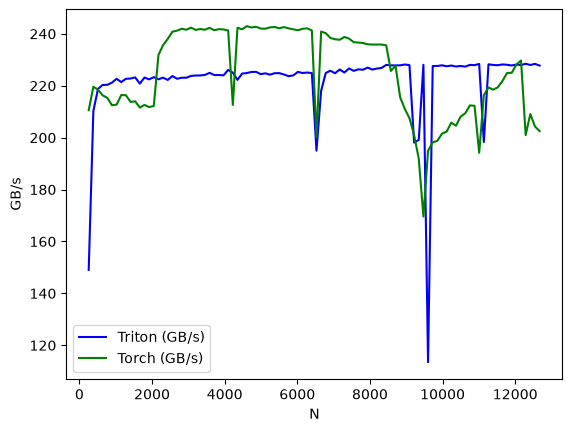

softmax-performance:
          N  Triton (GB/s)  Torch (GB/s)
0     256.0     149.056360    210.547242
1     384.0     210.288429    219.617698
2     512.0     218.797483    218.456705
3     640.0     220.306885    216.299463
4     768.0     220.336551    215.318637
5     896.0     221.205058    212.485474
6    1024.0     222.663679    212.724129
7    1152.0     221.407068    216.409467
8    1280.0     222.670020    216.354112
9    1408.0     222.765308    213.769918
10   1536.0     223.210771    213.991867
11   1664.0     220.792023    211.567697
12   1792.0     223.169109    212.608435
13   1920.0     222.436050    211.759383
14   2048.0     223.302850    212.212126
15   2176.0     222.472753    231.829663
16   2304.0     223.099073    235.640150
17   2432.0     222.233729    238.020366
18   2560.0     223.741668    240.811059
19   2688.0     222.688953    241.210140
20   2816.0     223.082645    241.959813
21   2944.0     223.082277    241.583776
22   3072.0     223.772184    242.38

In [5]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot 用作图表 x 轴的参数名
        x_vals=[128 * i for i in range(2, 100)],  # different possible values for `x_name` `x_name` 的不同可能值
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot 参数名，其值对应于图表中不同线条
        line_vals=['triton', 'torch'],  # possible values for `line_arg`` `line_arg` 的可能值
        line_names=[
            "Triton",
            "Torch",
        ],  # label name for the lines 线条的标签名称
        styles=[('blue', '-'), ('green', '-')],  # line styles 线条的样式
        ylabel="GB/s",  # label name for the y-axis y 轴的标签名称
        plot_name="softmax-performance",  # name for the plot. Used also as a file name for saving the plot. 图表的名称，也用作保存图表的文件名
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name` `x_names` 和 `y_name` 中未包含的函数参数的值
    ))
def benchmark(M, N, provider):
    x = torch.randn(M, N, device='cuda', dtype=torch.float32)
    stream = torch.cuda.Stream()
    torch.cuda.set_stream(stream)
    if provider == 'torch':
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    if provider == 'triton':
        ms = triton.testing.do_bench(lambda: softmax(x))
    gbps = lambda ms: 2 * x.nelement() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)




benchmark.run(show_plots=True, print_data=True)